In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Function to approximate sin(x) using Taylor Series
def taylor_sin(x, num_terms):
    """
    Approximates sin(x) using the Maclaurin series (Taylor series at a=0).
    
    Parameters:
    x (float or array): The value(s) to approximate sin(x) for.
    num_terms (int): The number of terms to use in the series.
    
    Returns:
    float or array: The approximated value of sin(x).
    """
    approximation = 0
    for n in range(num_terms):
        # The general term for sin(x) is (-1)^n * x^(2n+1) / (2n+1)!
        term = ((-1)**n * x**(2 * n + 1)) / math.factorial(2 * n + 1)
        approximation += term
    return approximation

In [2]:
# Define x values from 0 to 10 with steps of 0.1
x_values = np.arange(0, 10.1, 0.1)

# Calculate exact values using numpy
exact_values = np.sin(x_values)

# Initialize dictionaries to store approximations and errors
approximations = {}
errors = {}
term_counts = [1, 2, 3, 4]

# Loop through the specific term counts required
for k in term_counts:
    # Calculate approximation for k terms
    approx_val = taylor_sin(x_values, k)
    approximations[k] = approx_val
    
    # Calculate absolute error
    error_val = np.abs(approx_val - exact_values)
    errors[k] = error_val

    # Print a preview of data for the first few points (optional verification)
    print(f"Computed approximation using {k} term(s).")

Computed approximation using 1 term(s).
Computed approximation using 2 term(s).
Computed approximation using 3 term(s).
Computed approximation using 4 term(s).


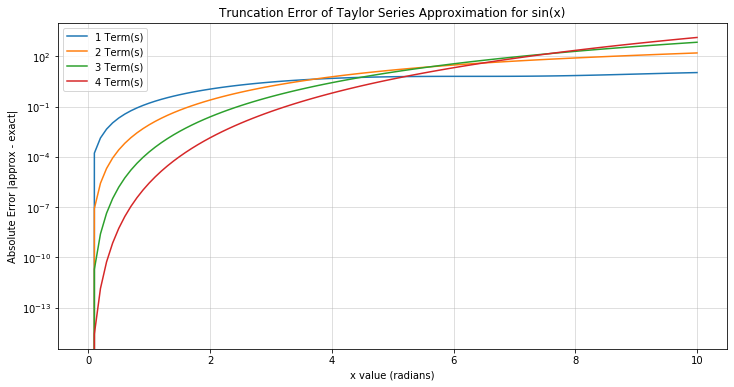

In [3]:
plt.figure(figsize=(12, 6))

# Plot the error for each number of terms
for k in term_counts:
    plt.plot(x_values, errors[k], label=f'{k} Term(s)')

plt.title('Truncation Error of Taylor Series Approximation for sin(x)')
plt.xlabel('x value (radians)')
plt.ylabel('Absolute Error |approx - exact|')
plt.yscale('log') # Log scale helps visualize the rapid growth of error
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Including more terms in the Taylor series generally improves accuracy and widens the range where the approximation is valid, but this improvement is not uniform. Since the series is centered at $x=0$, the error is negligible for small values of $x$, where the series converges rapidly. However, for larger values of $x$ (e.g., $x > 4$), the error grows exponentially because the power terms (like $x^7$, $x^9$) dominate the factorial denominators. Consequently, the approximation diverges significantly from the actual $\sin(x)$ curve at higher values unless a much larger number of terms is used.